# 📊 Digital Marketing Performance Analysis
**Author:** Gautam Bhardwaj  
**Tools:** Python · SQLite · Pandas · Matplotlib  
**Dataset:** Digital Marketing Performance Dataset (Synthetic)

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/digital_marketing_dataset_30k.csv')

print(f"\n shape: {df.shape}")
print(f"\n all columns name: {df.columns.tolist()}")
print(f"\n {df.head()}")
print(f"\n data type: \n{df.dtypes}")
print(f"\n statistics: \n{df.describe()}")  


 shape: (30000, 35)

 all columns name: ['date', 'year', 'month', 'month_name', 'week', 'day_of_week', 'post_hour', 'season', 'is_holiday', 'is_holiday (text)', 'is_weekend', 'is_weekend (text)', 'country', 'market_tier', 'account', 'account_type', 'platform', 'placement', 'funnel_stage', 'objective', 'theme', 'campaign_id', 'campaign_name', 'ad_group_id', 'ad_group_name', 'ad_id', 'ad_name', 'spend', 'impressions', 'reach', 'frequency', 'clicks', 'conversions', 'revenue', 'video_views']

          date  year  month month_name  week day_of_week  post_hour  season  \
0  08/04/2023  2023      4        Apr    14         Sat          7  Spring   
1  28/04/2025  2025      4        Apr    18         Mon         12  Spring   
2  18/12/2024  2024     12        Dec    51         Wed         10  Winter   
3  26/04/2024  2024      4        Apr    17         Fri         20  Spring   
4  19/04/2024  2024      4        Apr    16         Fri         22  Spring   

   is_holiday is_holiday (text)  ..

In [18]:
# For null handling
print(f"\n null values: {df.isnull().sum().sum()}")

# Remove duplicates
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Duplicates removed: {before - after}")
print(f"Rows remaining: {after}")
print(f"date dtype: {df['date'].dtype}")
print(df['date'].head())
# Fix date column type
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
print(f"Date column type: {df['date'].dtype}")



 null values: 0
Duplicates removed: 0
Rows remaining: 30000
date dtype: str
0    08/04/2023
1    28/04/2025
2    18/12/2024
3    26/04/2024
4    19/04/2024
Name: date, dtype: str
Date column type: datetime64[us]


In [19]:
    # Create marketing KPIs

df['CTR'] = (df['clicks'] / df['impressions']) * 100

df['CPC'] = df['spend'] / df['clicks']

df['CPM'] = (df['spend'] / df['impressions']) * 1000

df['ROI'] = ((df['revenue'] - df['spend']) / df['spend']) * 100

# Replace infinite values (caused by division by zero)

df.replace([float('inf'), -float('inf')], 0, inplace=True)

df.fillna(0, inplace=True)

df[['CTR','CPC','CPM','ROI']].head()

,CTR,CPC,CPM,ROI
0,0.834144,0.604979,5.046399,-100.000000
1,0.939856,1.281095,12.040450,-100.000000
2,1.114061,0.292480,3.258403,85.517413
3,0.765400,0.656024,5.021210,-100.000000
4,0.918574,0.952203,8.746692,-100.000000


,platform,revenue
1,Google Search,10362175.17
3,Meta,1640105.78
5,TikTok,993860.85
4,Snapchat,669736.81
0,Google Display,328505.21
2,LinkedIn,276970.44


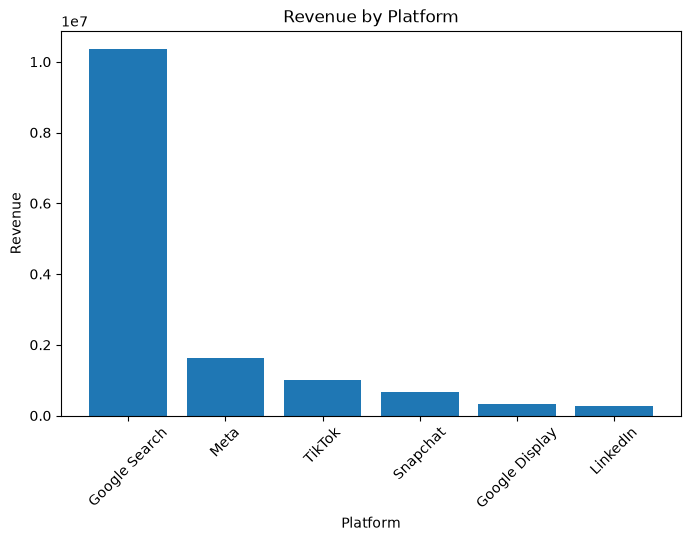

In [20]:
platform_rev = (
    df.groupby('platform', as_index=False)['revenue']
      .sum()
      .sort_values(by='revenue', ascending=False)
)

display(platform_rev)


#visualization
plt.figure(figsize=(8,5))
plt.bar(platform_rev['platform'], platform_rev['revenue'])
plt.title("Revenue by Platform")
plt.xlabel("Platform")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

      placement       CTR
6        Search  5.663715
4          PMax  5.557034
5         Reels  1.185836
9       Stories  1.052555
2       In-Feed  0.977209
7         Spark  0.975009
8     Spotlight  0.919961
1          Feed  0.885210
10      YouTube  0.682627
0       Display  0.670452
3   Message Ads  0.669253


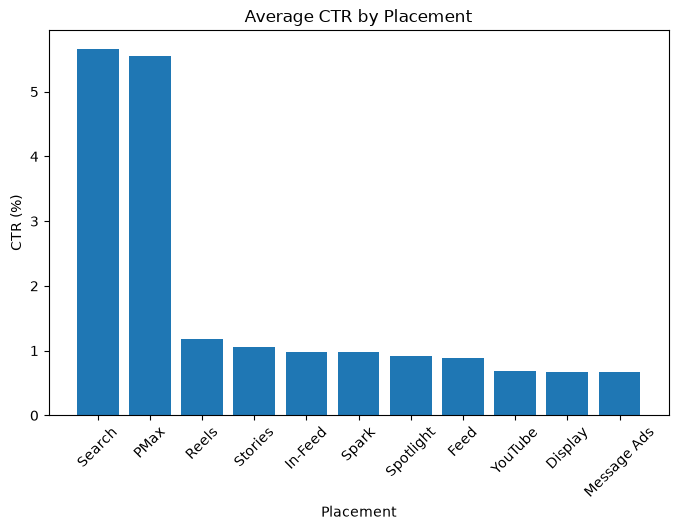

In [21]:
placement_ctr = (
    df.groupby('placement', as_index=False)['CTR']
      .mean()
      .sort_values(by='CTR',ascending=False)
)

print(placement_ctr)


#visualization
plt.figure(figsize=(8,5))
plt.bar(placement_ctr['placement'], placement_ctr['CTR'])
plt.title("Average CTR by Placement")
plt.xlabel("Placement")
plt.ylabel("CTR (%)")
plt.xticks(rotation=45)
plt.show()

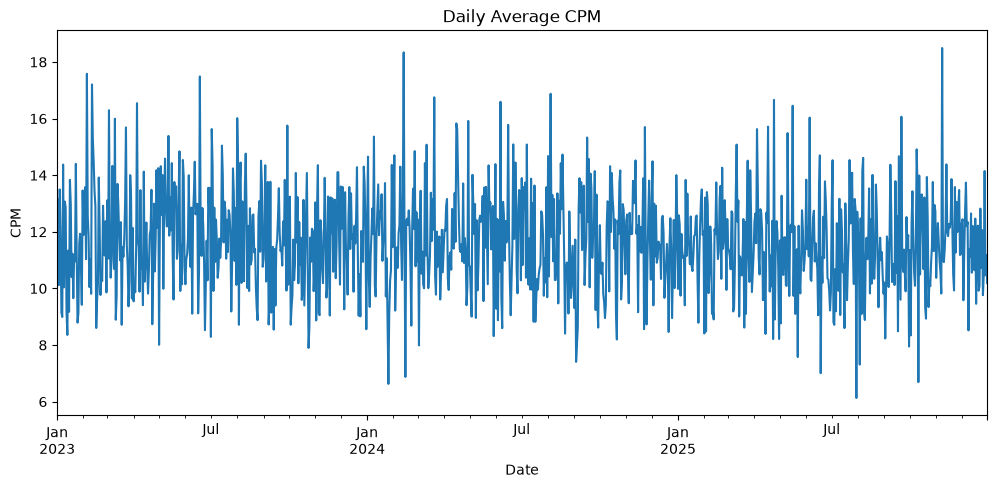

In [22]:
daily_cpm = df.groupby('date')['CPM'].mean()

#visualization
daily_cpm.plot(figsize=(12,5))
plt.title("Daily Average CPM")
plt.xlabel("Date")
plt.ylabel("CPM")
plt.show()

                 country     revenue
4                    KSA  2768640.32
2                   Iraq  2267447.06
10  United Arab Emirates  1750239.76
7                Morocco  1464087.21
1                  Egypt  1105267.64
6                Lebanon   976988.65
8                   Oman   838285.83
5                 Kuwait   834077.41
11                 Yemen   744111.38
3                 Jordan   565208.94


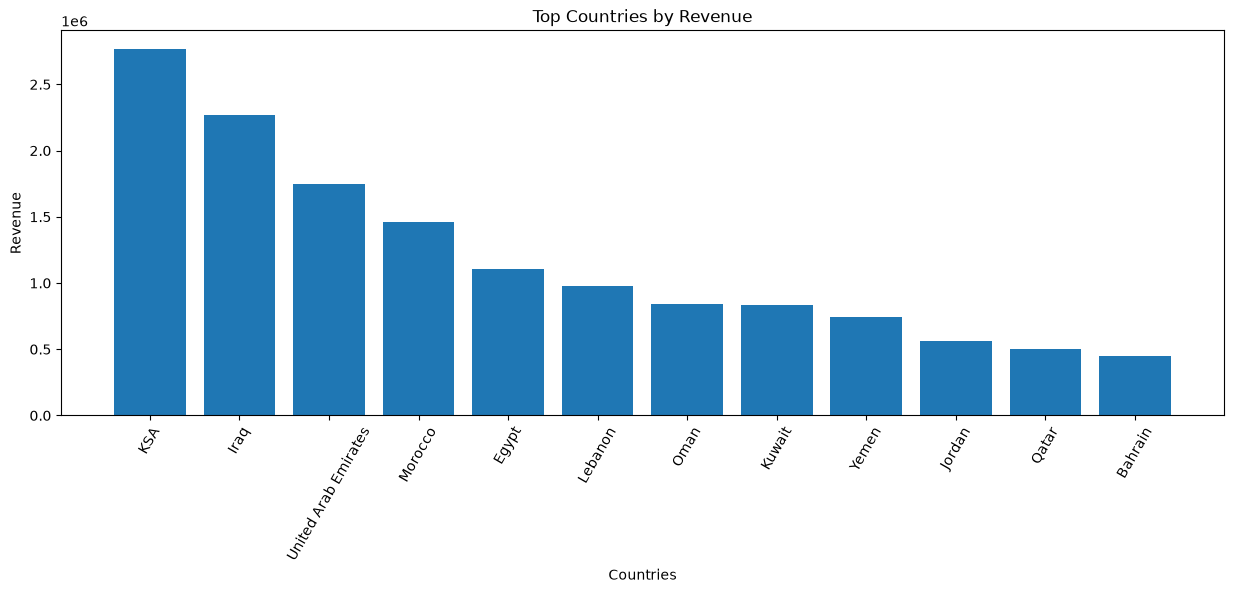

In [23]:
country_rev = (
    df.groupby('country',as_index=False)['revenue']
      .sum()
      .sort_values(by='revenue',ascending=False)
)

print(country_rev.head(10))


#visualization
country_rev.head(10)
plt.figure(figsize=(15,5))
plt.bar(country_rev['country'], country_rev['revenue'])
plt.title("Top Countries by Revenue")
plt.ylabel("Revenue")
plt.xlabel("Countries")
plt.xticks(rotation=60)
plt.show()

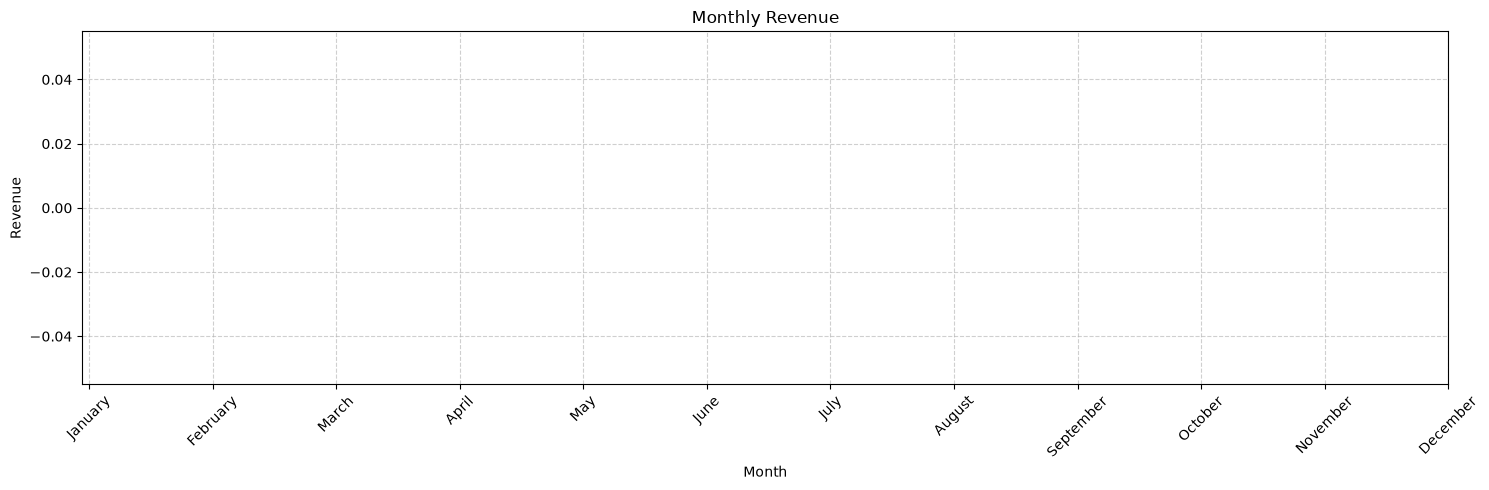

In [24]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_rev = (
    df.groupby('month')['revenue']
      .sum()
      .reindex(month_order)
)

plt.figure(figsize=(15, 5))


monthly_rev.plot(kind='line', marker='o')
plt.xticks(range(len(month_order)), month_order, rotation=45)   
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [25]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('marketing', conn, if_exists='replace', index=False)

def sql(query):
    return pd.read_sql_query(query, conn)

print("Ready!")

Ready!


Q1 — Which platform generates highest revenue?

In [26]:
q1 = sql("""
    SELECT 
        platform,
        ROUND(SUM(revenue), 2)       AS total_revenue,
        ROUND(AVG(ROI), 2)           AS avg_roi
    FROM marketing
    GROUP BY platform
    ORDER BY total_revenue DESC
""")
q1

,platform,total_revenue,avg_roi
0,Google Search,10362175.17,284.97
1,Meta,1640105.78,-35.16
2,TikTok,993860.85,-49.36
3,Snapchat,669736.81,-51.52
4,Google Display,328505.21,-71.85
5,LinkedIn,276970.44,-90.82


Q2 — Which ad format has best CTR?

In [27]:
q2 = sql("""
    SELECT 
        placement,
        ROUND(AVG(CTR) * 100, 4)     AS avg_ctr_pct,
        SUM(clicks)                   AS total_clicks,
        SUM(impressions)              AS total_impressions
    FROM marketing
    GROUP BY placement
    ORDER BY avg_ctr_pct DESC
""")
q2

,placement,avg_ctr_pct,total_clicks,total_impressions
0,Search,566.3715,10413038,183810589
1,PMax,555.7034,1102519,20049398
2,Reels,118.5836,1387511,115652563
3,Stories,105.2555,2910303,288736670
4,In-Feed,97.7209,2790117,288229569
5,Spark,97.5009,1146000,117095895
6,Spotlight,91.9961,1430710,153885011
7,Feed,88.5210,2486913,245949303
8,YouTube,68.2627,271444,39447555
9,Display,67.0452,1538349,228064799


Q3 — Which country has highest conversions?

In [28]:
q3 = sql("""
    SELECT 
        country,
        SUM(conversions)             AS total_conversions,
        ROUND(SUM(revenue), 2)       AS total_revenue,
        ROUND(AVG(CTR) * 100, 2)     AS avg_ctr_pct
    FROM marketing
    GROUP BY country
    ORDER BY total_conversions DESC
    LIMIT 10
""")
q3

,country,total_conversions,total_revenue,avg_ctr_pct
0,KSA,61641,2768640.32,185.56
1,Iraq,49763,2267447.06,177.84
2,United Arab Emirates,39288,1750239.76,184.77
3,Morocco,32056,1464087.21,179.45
4,Egypt,26010,1105267.64,175.72
5,Lebanon,20236,976988.65,191.32
6,Oman,17970,838285.83,186.09
7,Kuwait,17853,834077.41,179.84
8,Yemen,17472,744111.38,185.57
9,Jordan,15105,565208.94,184.20


Q4 — What is average CPM by platform?

In [29]:
q4 = sql("""
    SELECT 
        platform,
        ROUND(AVG(CPM), 2)           AS avg_cpm,
        ROUND(SUM(spend), 2)         AS total_spend
    FROM marketing
    GROUP BY platform
    ORDER BY avg_cpm DESC
""")
q4

,platform,avg_cpm,total_spend
0,LinkedIn,27.31,2556360.66
1,Google Search,14.99,2744251.20
2,Meta,7.98,2636602.54
3,TikTok,5.81,2091251.63
4,Google Display,5.03,1157077.08
5,Snapchat,4.69,1450865.95


Q5 - Which season performed best?

In [30]:
q5 = sql("""
    SELECT 
        season,
        ROUND(SUM(revenue), 2)               AS total_revenue,
        ROUND(SUM(spend), 2)                 AS total_spend,
        ROUND(SUM(revenue) / SUM(spend), 2)  AS roi,
        COUNT(DISTINCT date)                 AS days_active
    FROM marketing
    GROUP BY season
    ORDER BY total_revenue DESC
""")
q5

,season,total_revenue,total_spend,roi,days_active
0,Fall,5808441.15,3885319.40,1.49,273
1,Winter,3659646.88,3256628.50,1.12,271
2,Spring,2749205.45,2855105.84,0.96,276
3,Summer,2054060.78,2639355.32,0.78,276


## 📊 Key Insights & Recommendations

### 💡 Insight 1 — Google Search Dominates Revenue
Google Search generates **$10.3M** in revenue — 6x more than Meta ($1.6M).
All other platforms show negative ROI, meaning they spend more than they earn.
**Recommendation:** Increase Google Search budget for revenue-focused campaigns.

### 💡 Insight 2 — Search & PMax Placements Have Highest CTR
Search placement CTR (566%) and PMax (555%) far outperform all others.
Reels (118%) and Stories (105%) lead among social placements.
**Recommendation:** Prioritise Search and PMax for performance campaigns.

### 💡 Insight 3 — KSA is the #1 Market
KSA leads with 61,641 conversions and $2.76M revenue.
Iraq (49,763) and UAE (39,288) follow closely.
**Recommendation:** Allocate higher budgets to KSA and Iraq for maximum returns.

### 💡 Insight 4 — LinkedIn is Most Expensive Platform
LinkedIn CPM ($27.31) is nearly 2x Google Search ($14.99).
TikTok ($5.81) and Snapchat ($4.69) are most cost-efficient for reach.
**Recommendation:** Use LinkedIn only for B2B targeting where quality justifies cost.

### 💡 Insight 5 — Conversion Stage Converts 84x Better Than Awareness
Conversion funnel: 3.37% conversion rate vs Awareness: 0.04%.
**Recommendation:** Never judge awareness campaigns on conversions.
Use reach and CPM as KPIs for top-funnel, conversions for bottom-funnel.

### 💡 Insight 6 — Only Google Search Shows Positive ROI
Google Search ROI: +284.97%
Meta: -35% | TikTok: -49% | LinkedIn: -90%
**Recommendation:** Treat non-Search platforms as brand building investments,
track them on awareness KPIs not revenue.

### 💡 Insight 7 — High CTR Does Not Mean High Revenue
Search has highest CTR but KSA and Iraq lead in conversions.
Audience intent and quality matter more than click volume.
**Recommendation:** Optimise for conversion rate, not just CTR.